# Aplicación a la especie foco

Embudo de compuestos huérfanos con actividad fenotípica contra la especie foco
(`tdr.SP_FOCO`, un protozoo parásito) y
propuesta de blancos para los que el método puede tratar:

  1. compuestos con bioactividad fenotípica positiva contra la especie foco;
  2. de esos, los que **no** tienen ningún enlace de bioactividad a un blanco
     proteico (huérfanos en el sentido del paper);
  3. de esos, los tratables: con al menos un vecino químico con blanco conocido.

Para cada tratable se arma la semilla con su vecindario y se propaga; se conservan
las proteínas con `rG ≤ r*G`, el corte estimado en el notebook `03`.

Origen: la aplicación a la especie foco de la versión v3 (fuera de este repositorio).
Salidas: `04_embudo.csv`, `04_compuestos.csv`, `04_sugerencias.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path
# raiz del repositorio: se busca hacia arriba la carpeta que tiene DB/,
# asi el notebook corre desde donde sea que se haya clonado
RAIZ = Path.cwd()
while not (RAIZ / "DB").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "comun"))
sys.path.insert(0, str(RAIZ / "huerfanas"))
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_huerfanas as fh              # el .py de esta carpeta
import figuras as F                        # comun/figuras.py: las figuras, desde las tablas

SALIDAS = tdr.out("huerfanas")
FIGURAS = SALIDAS / "figuras"
NB      = "04"                             # numero de este notebook: prefija todo lo que genere
n_core  = tdr.N_CORE_DEFAULT                # 20 salvo TDR_NCORE

plt = tdr.estilo()
SALIDAS

PosixPath('/data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out')

## Datos

In [2]:
# cluster_consistent=True: `huerfanas/` filtra los positivos/negativos
# inconsistentes a nivel cluster, como en la versión v3.
crudo = tdr.cargar_db(anotaciones=True, quimica=True, fenotipo=True, cluster_consistent=True)

# CONVENCIONES.md §10: el filtro de promiscuidad se APLICA antes de armar ninguna semilla.
# La lista sale de analiceDB/03; si falta, el error dice qué correr.
promiscuos = tdr.compuestos_promiscuos()
datos = tdr.filtrar_capa_quimica(crudo, promiscuos)

HUERFANAS = tdr.out("huerfanas")
rg_star = float(pd.read_csv(HUERFANAS / "03_rg_estrella.csv")["r_g_estrella"].iloc[0])
optimos = fh.parametros_optimos()
print(f"corte r*G = {rg_star:.0f}  ·  parámetros de sp{tdr.SP_FOCO}: {optimos[tdr.SP_FOCO]}")

· 00_specie_target


· 03_bioactivities_target_compound


· 04a_interpro / 04b_orthomcl


· 01/02 clusters y aristas quimicas (pesado)


· 03_bioactivities_organism_compound


filtro de promiscuidad (MW < 150 y N_parentales > 100): 5 compuestos


  sclus 831175 -> 831170 (0.00 % removido)


  dds   440 -> 440 (0.00 % removido)


corte r*G = 74  ·  parámetros de sp26: (1.2, 1.0, 1.0, 0.8)


## Acondicionamiento

In [3]:
SP = tdr.SP_FOCO   # Plasmodium falciparum; ver tdr.SPECIES
embudo, compuestos = fh.embudo_especie(datos, sp=SP)
tratables = compuestos.loc[compuestos["tratable"], "drug_id"].values
print(embudo.to_string(index=False))


                               paso   n
        1 - fenotípicamente activos 174
2 - sin blanco proteico (huérfanos)   3
        3 - tratables por el método   3


## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
ctx = fh.preparar_especie(datos, SP, optimos[SP], pd.DataFrame({"sp_id": []}))
posdt_sp = datos.posdt.merge(datos.st[["target_id", "sp_id"]], on="target_id", how="left")
fh.fijar_contexto(datos, posdt_sp, ctx)

sugerencias = []
for cid in tratables:
    seed = fh.semilla_de_droga(datos, cid, datos.posdt[["drug_id", "target_id"]],
                               consolidar=True)
    if seed is None or seed.empty:
        continue
    rnk = tdr.propagar(datos.sta, seed, ctx["cat_rs"], beta=ctx["beta"],
                       lambda_=ctx["lambda_"], gamma=ctx["gamma"])
    rnk["rG"] = rnk["score"].rank(ascending=False, method="average")
    top = rnk[(rnk["rG"] <= rg_star) & rnk["target_id"].astype(str).isin(ctx["sp_targets"])]
    sugerencias.append(top.assign(drug_id=cid))

sug = pd.concat(sugerencias, ignore_index=True) if sugerencias else pd.DataFrame()
# Familias de blancos mas sugeridas. Las anotaciones van por codigo: nombrarlas
# exige `mapa_interpro`, que es privado (PROVENANCE.md §6); `ipr={}` evita
# que `anotar_targets` intente resolver los nombres.
if len(sug):
    fam = tdr.anotar_targets(sug["target_id"].unique(), datos.sta, ipr={})
    familias = (sug.merge(fam, on="target_id", how="left")
                .groupby("anotaciones")["drug_id"].nunique()
                .rename("compuestos").reset_index())
else:
    familias = pd.DataFrame(columns=["anotaciones", "compuestos"])

embudo.to_csv(SALIDAS / f"{NB}_embudo.csv", index=False)
compuestos.to_csv(SALIDAS / f"{NB}_compuestos.csv", index=False)
sug.to_csv(SALIDAS / f"{NB}_sugerencias.csv", index=False)
familias.to_csv(SALIDAS / f"{NB}_familias.csv", index=False)
fh.escribir_meta(SALIDAS, NB, notebook="04_aplicacion_especie.ipynb",
                 params={"especie": SP, "r_g_estrella": rg_star, "optimos": optimos[SP]},
                 n_core=n_core, filtro_promiscuidad=True)

  meta -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/04_meta.json


{'notebook': '04_aplicacion_especie.ipynb',
 'nb': '04',
 'fecha': '2026-09-10 11:06',
 'params': {'especie': 26,
  'r_g_estrella': 74.0,
  'optimos': [1.2, 1.0, 1.0, 0.8]},
 'n_core': 20,
 'tablas_db': {'00_specie_target.csv': '2026-09-08',
  '01_clusters_fingerprint.csv': '2026-09-08',
  '01_edges_clusters_fingerprint.part00.csv.gz': '2026-09-08',
  '01_edges_clusters_fingerprint.part01.csv.gz': '2026-09-08',
  '02_clusters_subestructure.csv': '2026-09-08',
  '02_edges_clusters_subestructure.csv': '2026-09-08',
  '03_bioactivities_organism_compound.csv': '2026-09-08',
  '03_bioactivities_target_compound.csv': '2026-09-08',
  '04a_interpro.csv': '2026-09-08',
  '04b_orthomcl.csv': '2026-09-08'},
 'python': '3.12.11',
 'pandas': '3.0.5',
 'filtro_promiscuidad': True}

# Resultados

Desde acá no se toca la base: cada figura lee sus tablas de `resultados/` y la
dibuja `F.dibujar(...)` (las funciones están en `figuras_huerfanas.py`). Para
regenerarlas sin volver a pagar la corrida alcanza con la celda de imports y esta
sección, o, desde la raíz del repositorio:

    python comun/figuras.py huerfanas

In [5]:
embudo     = pd.read_csv(SALIDAS / f"{NB}_embudo.csv")
compuestos = pd.read_csv(SALIDAS / f"{NB}_compuestos.csv")
# El archivo de sugerencias puede quedar vacío: es un resultado, no un fallo.
# Con la base recortada quedan pocos compuestos huérfanos tratables, y puede que
# ninguno reciba un blanco por debajo del corte r*G.
try:
    sug = pd.read_csv(SALIDAS / f"{NB}_sugerencias.csv")
except pd.errors.EmptyDataError:
    sug = pd.DataFrame(columns=["drug_id", "target_id", "score", "rG"])

print(embudo.to_string(index=False))
if len(sug):
    print(f"\n{sug['drug_id'].nunique()} compuestos con sugerencias, "
          f"{sug['target_id'].nunique()} blancos propuestos")
else:
    print(f"\nsin sugerencias: los {int(embudo['n'].iloc[-1])} compuestos tratables "
          f"no reciben ningún blanco por debajo de r*G = {rg_star:.0f}")
sug.head(20)

                               paso   n
        1 - fenotípicamente activos 174
2 - sin blanco proteico (huérfanos)   3
        3 - tratables por el método   3

sin sugerencias: los 3 compuestos tratables no reciben ningún blanco por debajo de r*G = 74


,drug_id,target_id,score,rG


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/04_f01_embudo.pdf


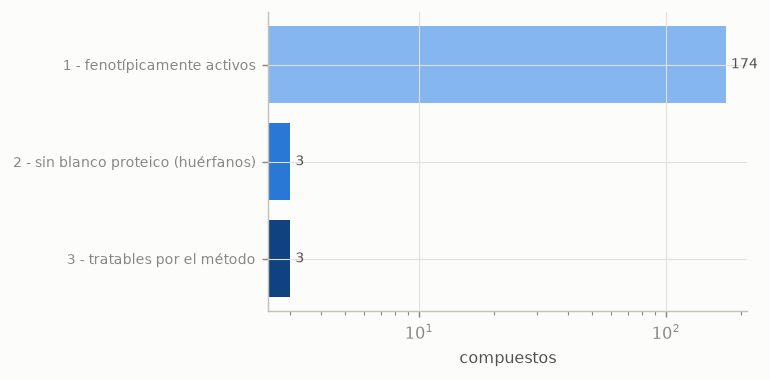

In [6]:
F.dibujar("04_f01_embudo");

In [7]:
# Sin sugerencias bajo r*G las dos figuras devuelven None y no se guarda nada.
F.dibujar("04_f02_rg_sugerencias");
F.dibujar("04_f03_familias");